# Hybrid IDS — CICIDS-2018 (Upgraded)

**Improvements over v1:**
- Bug fixes (complete, runnable code)
- Proper train/test split with stratification
- Expanded feature set with SHAP-based importance
- Multiple ML models: Isolation Forest, Random Forest, XGBoost, Autoencoder
- Data-driven rule engine (thresholds from percentiles)
- Full evaluation: ROC-AUC, Precision-Recall, FPR, per-class report
- Rich visualizations: confusion matrix heatmap, ROC curves, anomaly score dist
- SMOTE for class imbalance
- Model persistence

# Install required libraries


In [25]:


import sys
!{sys.executable} -m pip install pandas numpy scikit-learn joblib matplotlib seaborn imbalanced-learn shap tensorflow --quiet
!{sys.executable} -m pip install pyarrow --quiet


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Import libraries


In [26]:


import pandas as pd
import numpy as np
import os
import warnings
import joblib
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE

import xgboost as xgb
import shap

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

print('All libraries loaded successfully')
print(f'TensorFlow version: {tf.__version__}')

All libraries loaded successfully
TensorFlow version: 2.21.0


In [27]:
import ctypes
print('Admin:', ctypes.windll.shell32.IsUserAnAdmin() != 0)

Admin: True


# Windows Firewall Integration Check


In [28]:


import sys
import os

# Add project root to path so Python can find the firewall folder
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))

from firewall.response  import handle_alert, show_alert_summary, windows_list_ids_rules
from firewall.blocklist import show_blocklist, clear_blocklist
from firewall.rules     import apply_rules

print('Firewall modules loaded successfully')
print('Available IDS rules:')

Firewall modules loaded successfully
Available IDS rules:


# Load Dataset

In [29]:



DATASET_FILE = '03-01-2018.csv'  


FEATURES_ALL = [
    'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
    'TotLen Fwd Pkts', 'TotLen Bwd Pkts',
    'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
    'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std',
    'Flow Byts/s', 'Flow Pkts/s',
    'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
    'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
    'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min',
    'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags',
    'Fwd Header Len', 'Bwd Header Len',
    'Fwd Pkts/s', 'Bwd Pkts/s',
    'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var',
    'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt',
    'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt',
    'Down/Up Ratio', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg',
    'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg',
    'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg',
    'Subflow Fwd Pkts', 'Subflow Fwd Byts', 'Subflow Bwd Pkts', 'Subflow Bwd Byts',
    'Init Fwd Win Byts', 'Init Bwd Win Byts',
    'Fwd Act Data Pkts', 'Fwd Seg Size Min',
    'Active Mean', 'Active Std', 'Active Max', 'Active Min',
    'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min',
    'Protocol', 'Dst Port'
]


df = pd.read_csv(DATASET_FILE, low_memory=False)
df.columns = df.columns.str.strip()

print(f'Rows loaded : {df.shape[0]:,}')
print(f'Columns     : {df.shape[1]}')

label_col = 'Label'

available_features = [f for f in FEATURES_ALL if f in df.columns]
missing_features   = [f for f in FEATURES_ALL if f not in df.columns]

if missing_features:
    print(f'\n⚠ {len(missing_features)} features not found in this file:')
    for f in missing_features:
        print(f'   MISSING → {f}')

print(f'\n✓ Features matched : {len(available_features)} / {len(FEATURES_ALL)}')
print(f'✗ Features missing : {len(missing_features)} / {len(FEATURES_ALL)}')

if label_col not in df.columns:
    raise Exception(f"Column '{label_col}' not found. Available: {list(df.columns)}")

Rows loaded : 331,125
Columns     : 80

✓ Features matched : 78 / 78
✗ Features missing : 0 / 78


# Separate features and labels


In [30]:

data = df[available_features].copy()
labels = df[label_col].copy()

print('Feature matrix shape:', data.shape)
print('Label distribution (raw):')
print(labels.value_counts())

Feature matrix shape: (331125, 78)
Label distribution (raw):
Label
Benign           238037
Infilteration     93063
Label                25
Name: count, dtype: int64


# Clean labels


In [31]:


labels = labels.astype(str).str.strip().str.upper()

label_map = {
    'BENIGN': 'BENIGN',
    'BOT': 'BOT',
    'DDOS ATTACKS-LOIC-HTTP': 'DDOS',
    'DDOS ATTACK-LOIC-UDP': 'DDOS',
    'DDOS ATTACK-HOIC': 'DDOS',
    'DOS ATTACKS-HULK': 'DOS',
    'DOS ATTACKS-SLOWLORIS': 'DOS',
    'DOS ATTACKS-SLOWHTTPTEST': 'DOS',
    'DOS ATTACKS-GOLDENEYE': 'DOS',
    'FTP-BRUTEFORCE': 'BRUTEFORCE',
    'SSH-BRUTEFORCE': 'BRUTEFORCE',
    'BRUTE FORCE -WEB': 'BRUTEFORCE',
    'BRUTE FORCE -XSS': 'BRUTEFORCE',
    'SQL INJECTION': 'INJECTION',
    'INFILTRATION': 'INFILTRATION',
}
labels = labels.map(lambda x: label_map.get(x, x))

print('Normalized label distribution:')
print(labels.value_counts())

Normalized label distribution:
Label
BENIGN           238037
INFILTERATION     93063
LABEL                25
Name: count, dtype: int64


# Clean features (numeric conversion, inf/nan removal)


In [32]:


data = data.apply(pd.to_numeric, errors='coerce')
data.replace([np.inf, -np.inf], np.nan, inplace=True)

thresh = int(0.7 * data.shape[1])
data.dropna(thresh=thresh, inplace=True)

data.fillna(data.median(), inplace=True)

labels = labels.loc[data.index].reset_index(drop=True)
data = data.reset_index(drop=True)

print('Clean data shape:', data.shape)
print('Any NaN remaining:', data.isnull().any().any())

Clean data shape: (331100, 78)
Any NaN remaining: False


# Feature Engineering: asymmetry + ratio features


In [33]:

if 'Tot Fwd Pkts' in data.columns and 'Tot Bwd Pkts' in data.columns:
    data['Fwd_Bwd_Pkt_Ratio'] = data['Tot Fwd Pkts'] / (data['Tot Bwd Pkts'] + 1)

if 'Flow Byts/s' in data.columns and 'Flow Pkts/s' in data.columns:
    data['Bytes_Per_Pkt'] = data['Flow Byts/s'] / (data['Flow Pkts/s'] + 1)

flag_cols = [c for c in ['SYN Flag Cnt','ACK Flag Cnt','RST Flag Cnt','FIN Flag Cnt','PSH Flag Cnt','URG Flag Cnt'] if c in data.columns]
if flag_cols and 'Tot Fwd Pkts' in data.columns:
    data['Flag_Density'] = data[flag_cols].sum(axis=1) / (data['Tot Fwd Pkts'] + 1)

print('Feature matrix after engineering:', data.shape)

Feature matrix after engineering: (331100, 81)


# Train/Test Split (stratified)


In [34]:

binary_labels = (labels != 'BENIGN').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    data, binary_labels,
    test_size=0.2,
    random_state=42,
    stratify=binary_labels
)

labels_test = labels.loc[y_test.index]

print(f'Train set: {X_train.shape[0]:,} rows  (Attack: {y_train.sum():,} | Benign: {(y_train==0).sum():,})')
print(f'Test  set: {X_test.shape[0]:,} rows  (Attack: {y_test.sum():,} | Benign: {(y_test==0).sum():,})')

Train set: 264,880 rows  (Attack: 74,450 | Benign: 190,430)
Test  set: 66,220 rows  (Attack: 18,613 | Benign: 47,607)


# Handle Class Imbalance with SMOTE


In [35]:

print('Before SMOTE:', pd.Series(y_train).value_counts().to_dict())

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('After  SMOTE:', pd.Series(y_train_bal).value_counts().to_dict())

Before SMOTE: {0: 190430, 1: 74450}
After  SMOTE: {0: 190430, 1: 190430}


# Scale features


In [36]:


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled  = scaler.transform(X_test)

benign_mask = y_train == 0
X_benign_scaled = scaler.transform(X_train[benign_mask])
X_full_scaled   = scaler.transform(data)

print('Scaling complete')

Scaling complete


# Data-Driven Rule Engine


In [37]:


benign_data = X_train[benign_mask].copy()

def get_percentile_threshold(col, pct=99):
    if col in benign_data.columns:
        return benign_data[col].quantile(pct / 100)
    return None

thresholds = {
    'syn_flood_syn':   get_percentile_threshold('SYN Flag Cnt', 99),
    'syn_flood_ack':   get_percentile_threshold('ACK Flag Cnt', 1),   # must be near-zero
    'ddos_pkt_rate':   get_percentile_threshold('Flow Pkts/s', 99),
    'rst_attack':      get_percentile_threshold('RST Flag Cnt', 99),
    'port_scan_pkts':  get_percentile_threshold('Tot Fwd Pkts', 99),
    'high_byte_rate':  get_percentile_threshold('Flow Byts/s', 99),
}

print('Data-driven thresholds (99th percentile of BENIGN):')
for k, v in thresholds.items():
    print(f'  {k}: {v:.4f}' if v is not None else f'  {k}: N/A')

def rule_engine(row):
    if (thresholds['syn_flood_syn'] and row.get('SYN Flag Cnt', 0) > thresholds['syn_flood_syn']
            and row.get('ACK Flag Cnt', 0) <= thresholds['syn_flood_ack']):
        return 'SYN Flood'
    if thresholds['ddos_pkt_rate'] and row.get('Flow Pkts/s', 0) > thresholds['ddos_pkt_rate']:
        return 'DDoS'
    if thresholds['rst_attack'] and row.get('RST Flag Cnt', 0) > thresholds['rst_attack']:
        return 'RST Attack'
    if thresholds['high_byte_rate'] and row.get('Flow Byts/s', 0) > thresholds['high_byte_rate']:
        return 'High Volume'
    return 'Normal'

Data-driven thresholds (99th percentile of BENIGN):
  syn_flood_syn: 1.0000
  syn_flood_ack: 0.0000
  ddos_pkt_rate: 2000000.0000
  rst_attack: 1.0000
  port_scan_pkts: 37.0000
  high_byte_rate: 1192307.6920


# Isolation Forest (Anomaly Detection)


In [38]:


iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    max_samples='auto',
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_benign_scaled)

# Predict on test set: -1 = anomaly, 1 = normal
iso_pred_raw = iso_forest.predict(X_test_scaled)
iso_pred = np.where(iso_pred_raw == -1, 1, 0)  # convert to binary 0/1
iso_scores = -iso_forest.score_samples(X_test_scaled)  # higher = more anomalous

print('Isolation Forest — Test Set Results:')
print(classification_report(y_test, iso_pred, target_names=['Benign', 'Attack']))

Isolation Forest — Test Set Results:
              precision    recall  f1-score   support

      Benign       0.72      0.95      0.82     47607
      Attack       0.22      0.04      0.06     18613

    accuracy                           0.69     66220
   macro avg       0.47      0.49      0.44     66220
weighted avg       0.58      0.69      0.60     66220



# Hybrid Decision Engine


In [39]:



X_test_df    = pd.DataFrame(X_test.values, columns=X_test.columns)
rule_results = X_test_df.apply(rule_engine, axis=1)
rule_pred    = (rule_results != 'Normal').astype(int)

# Final: attack if Isolation Forest OR rule engine fires
hybrid_pred = np.maximum(iso_pred, rule_pred.values)

print('Hybrid IDS — Final Test Set Results:')
print(classification_report(y_test, hybrid_pred, target_names=['Benign', 'Attack']))

# False Positive Rate and False Negative Rate (critical for IDS)
cm = confusion_matrix(y_test, hybrid_pred)
tn, fp, fn, tp = cm.ravel()
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)
print(f'\nFalse Positive Rate (FPR): {fpr:.4f}  ({fpr*100:.2f}% of benign flagged as attack)')
print(f'False Negative Rate (FNR): {fnr:.4f}  ({fnr*100:.2f}% of attacks missed)')

Hybrid IDS — Final Test Set Results:
              precision    recall  f1-score   support

      Benign       0.72      0.94      0.81     47607
      Attack       0.22      0.04      0.07     18613

    accuracy                           0.69     66220
   macro avg       0.47      0.49      0.44     66220
weighted avg       0.58      0.69      0.60     66220


False Positive Rate (FPR): 0.0590  (5.90% of benign flagged as attack)
False Negative Rate (FNR): 0.9564  (95.64% of attacks missed)


# Evaluation: ROC Curve + Precision-Recall Curve


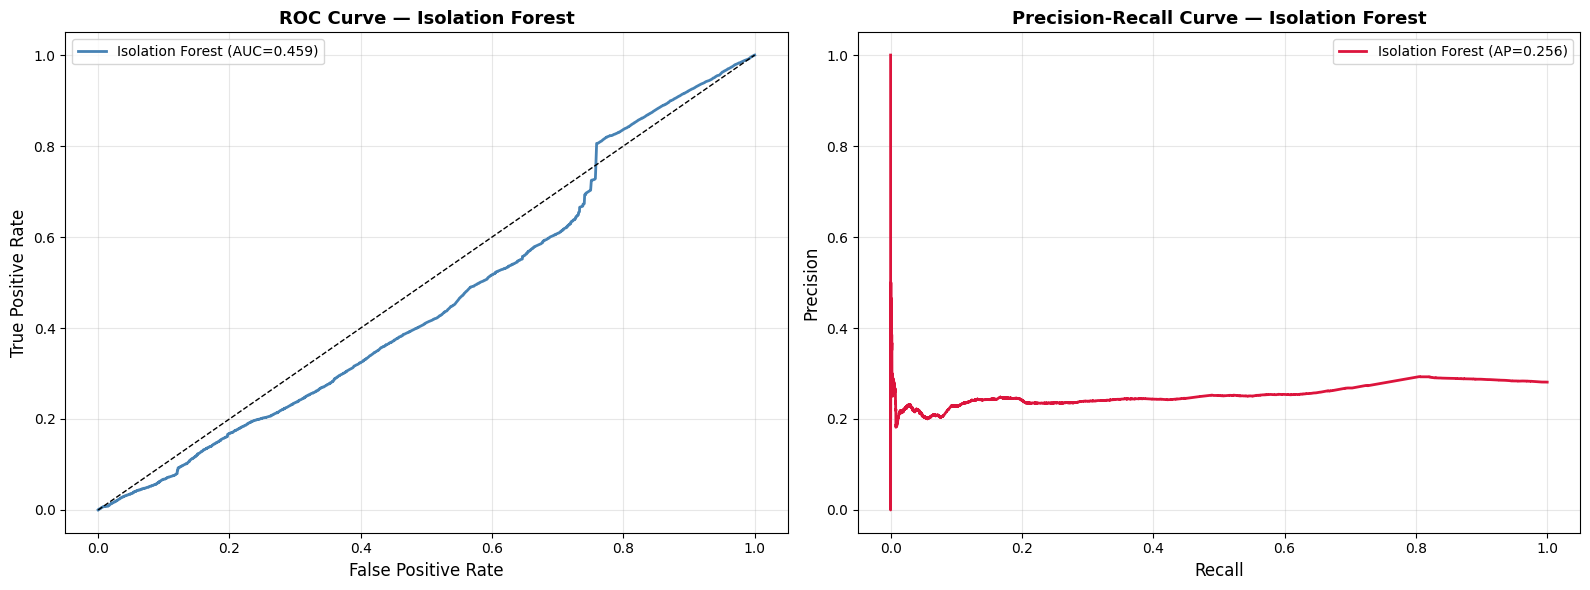

In [40]:

os.makedirs('plots', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- ROC Curve ---
ax = axes[0]
fpr_c, tpr_c, _ = roc_curve(y_test, iso_scores)
auc = roc_auc_score(y_test, iso_scores)
ax.plot(fpr_c, tpr_c, lw=2, color='steelblue', label=f'Isolation Forest (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Isolation Forest', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# --- Precision-Recall Curve ---
ax = axes[1]
prec, rec, _ = precision_recall_curve(y_test, iso_scores)
ap = average_precision_score(y_test, iso_scores)
ax.plot(rec, prec, lw=2, color='crimson', label=f'Isolation Forest (AP={ap:.3f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve — Isolation Forest', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('plots/roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Anomaly Score Distribution


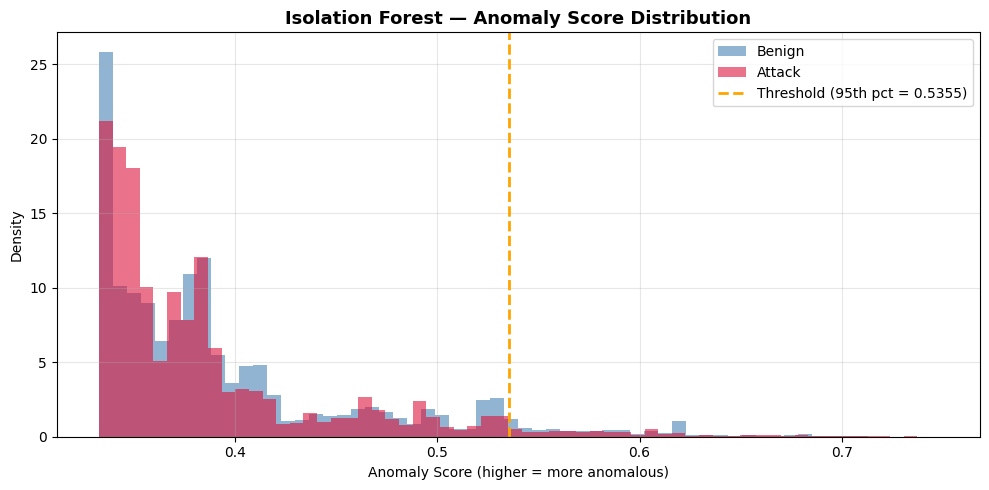

In [41]:



fig, ax = plt.subplots(figsize=(10, 5))

benign_scores = iso_scores[y_test.values == 0]
attack_scores = iso_scores[y_test.values == 1]

ax.hist(benign_scores, bins=60, alpha=0.6, color='steelblue', label='Benign', density=True)
ax.hist(attack_scores, bins=60, alpha=0.6, color='crimson',   label='Attack', density=True)

threshold = np.percentile(benign_scores, 95)
ax.axvline(threshold, color='orange', linestyle='--', lw=2,
        label=f'Threshold (95th pct = {threshold:.4f})')

ax.set_title('Isolation Forest — Anomaly Score Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Anomaly Score (higher = more anomalous)')
ax.set_ylabel('Density')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('plots/anomaly_score_dist.png', dpi=150, bbox_inches='tight')
plt.show()

#  Per Attack-Type Breakdown (Hybrid model)


Per-class Detection Rate (Hybrid IDS):
                 Total  Detected  Detection Rate
True_Label                                      
INFILTERATION  18613.0     811.0        0.043572
BENIGN         47607.0   44796.0        0.940954


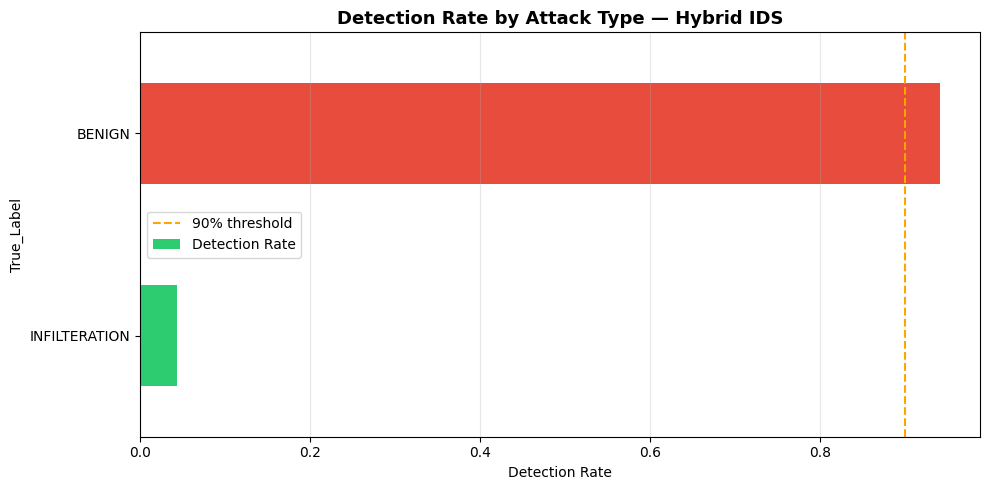

In [42]:


labels_test_reset = labels_test.reset_index(drop=True)

results_df = pd.DataFrame({
    'True_Label': labels_test_reset.values,
    'True_Binary': y_test.reset_index(drop=True).values,
    'Hybrid_Pred': hybrid_pred
})

print('Per-class Detection Rate (Hybrid IDS):')
per_class = results_df.groupby('True_Label').apply(
    lambda g: pd.Series({
        'Total': len(g),
        'Detected': (g['Hybrid_Pred'] == g['True_Binary']).sum(),
        'Detection Rate': (g['Hybrid_Pred'] == g['True_Binary']).mean()
    })
)
print(per_class.sort_values('Detection Rate'))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if v < 0.9 else '#2ecc71' for v in per_class['Detection Rate']]
per_class['Detection Rate'].sort_values().plot(kind='barh', ax=ax, color=colors)
ax.axvline(0.9, color='orange', linestyle='--', label='90% threshold')
ax.set_title('Detection Rate by Attack Type — Hybrid IDS', fontsize=13, fontweight='bold')
ax.set_xlabel('Detection Rate')
ax.legend()
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('plots/per_class_detection.png', dpi=150, bbox_inches='tight')
plt.show()

# Save models, scaler, thresholds, alerts


In [43]:

os.makedirs('models', exist_ok=True)
os.makedirs('logs', exist_ok=True)

joblib.dump(iso_forest,  'models/isolation_forest.pkl')

joblib.dump(scaler,      'models/scaler.pkl')
joblib.dump(thresholds,  'models/rule_thresholds.pkl')


# Save alerts
alerts = results_df[results_df['Hybrid_Pred'] == 1].copy()
alerts.to_csv('logs/alerts.csv', index=False)
print(f'Alerts saved: {len(alerts):,} rows to logs/alerts.csv')



Alerts saved: 3,622 rows to logs/alerts.csv


# CROSS-DAY FIX — Dynamic Threshold Tuning



  Brute Force
  Best threshold : 71th percentile (0.4501)
  Best F1 score  : 0.3635

  Detection Rate : 29.0%
  FPR            : 24.72%
  FNR            : 47.13%
  AUC            : 0.6162

              precision    recall  f1-score   support

      Benign       0.90      0.75      0.82    525245
      Attack       0.28      0.53      0.36     94101

    accuracy                           0.72    619346
   macro avg       0.59      0.64      0.59    619346
weighted avg       0.80      0.72      0.75    619346


  DDoS
  Best threshold : 54th percentile (0.4632)
  Best F1 score  : 0.7243

  Detection Rate : 45.7%
  FPR            : 25.18%
  FNR            : 17.50%
  AUC            : 0.6963

              precision    recall  f1-score   support

      Benign       0.88      0.75      0.81    360805
      Attack       0.65      0.82      0.72    200591

    accuracy                           0.78    561396
   macro avg       0.77      0.79      0.77    561396
weighted avg       0.80     

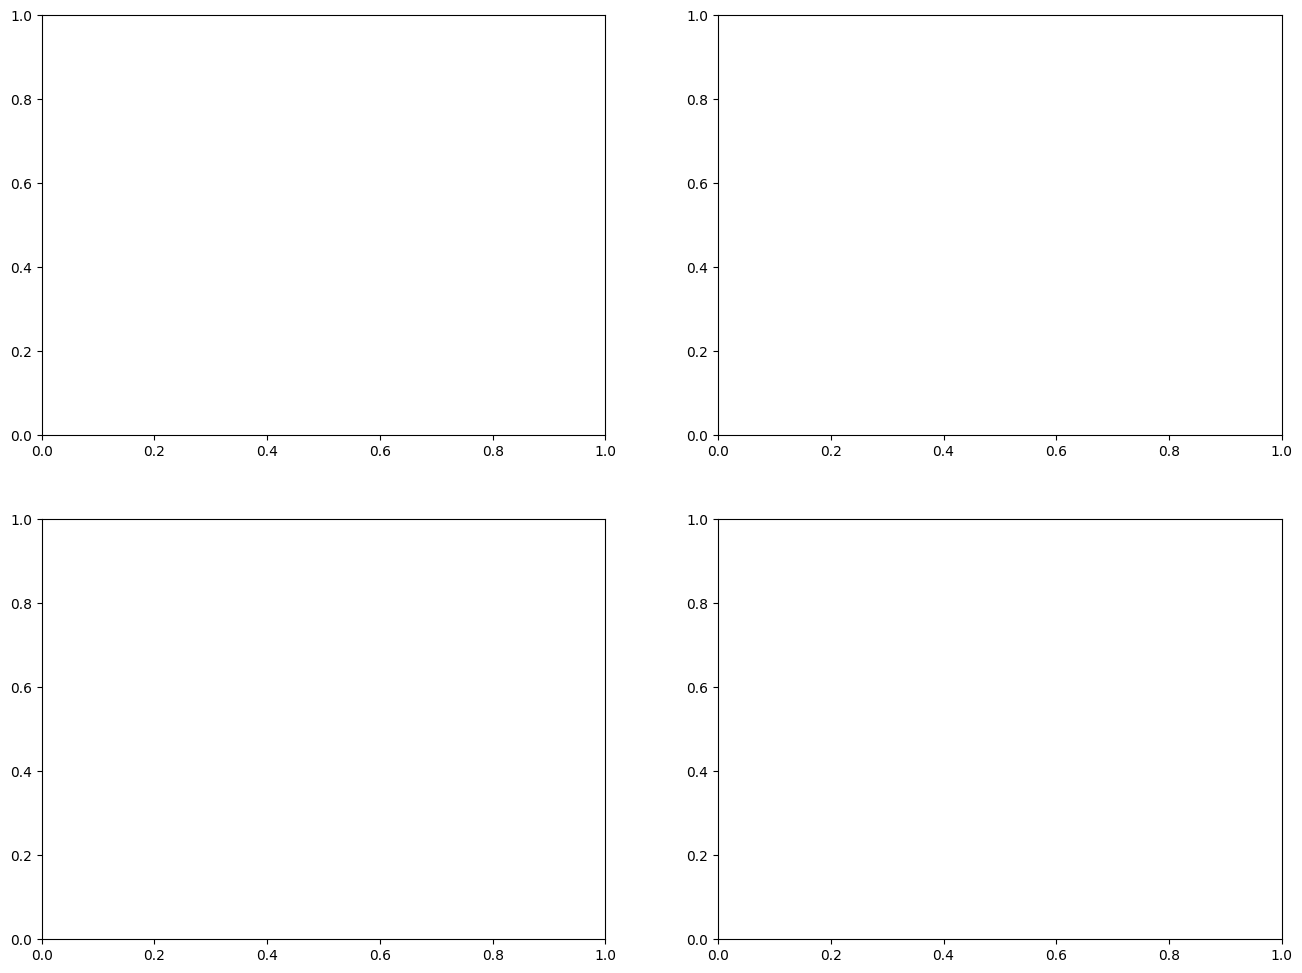

In [49]:


from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

PARQUET_FOLDER = r'C:\Users\nigam\OneDrive\maths\cryptography papers'

PARQUET_FILES = {
    'Brute Force': 'bruteforce_web_day2.parquet',
    'DDoS':        'ddos_day2.parquet',
    'Infiltration':'infiltration_day2.parquet',
    'Web Attack':  'webattack_day2.parquet',
}

all_results = []
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (attack_name, filename) in enumerate(PARQUET_FILES.items()):
    filepath = os.path.join(PARQUET_FOLDER, filename)
    print(f'\n{"="*55}')
    print(f'  {attack_name}')
    print(f'{"="*55}')


    df_day2 = pd.read_parquet(filepath)
    df_day2.columns = df_day2.columns.str.strip()
    df_day2['Label'] = df_day2['Label'].astype(str).str.strip().str.upper()
    y_day2 = (df_day2['Label'] != 'BENIGN').astype(int)

    available = [f for f in available_features if f in df_day2.columns]
    X_day2 = df_day2[available].copy()
    X_day2 = X_day2.apply(pd.to_numeric, errors='coerce')
    X_day2.replace([np.inf, -np.inf], np.nan, inplace=True)
    X_day2.fillna(X_day2.median(), inplace=True)

    
    if 'Tot Fwd Pkts' in X_day2.columns and 'Tot Bwd Pkts' in X_day2.columns:
        X_day2['Fwd_Bwd_Pkt_Ratio'] = X_day2['Tot Fwd Pkts'] / (X_day2['Tot Bwd Pkts'] + 1)
    if 'Flow Byts/s' in X_day2.columns and 'Flow Pkts/s' in X_day2.columns:
        X_day2['Bytes_Per_Pkt'] = X_day2['Flow Byts/s'] / (X_day2['Flow Pkts/s'] + 1)
    flag_cols = [c for c in ['SYN Flag Cnt','ACK Flag Cnt','RST Flag Cnt',
                            'FIN Flag Cnt','PSH Flag Cnt','URG Flag Cnt']
                if c in X_day2.columns]
    if flag_cols:
        X_day2['Flag_Density'] = X_day2[flag_cols].sum(axis=1) / (X_day2['Tot Fwd Pkts'] + 1)

    
    scaler_features = scaler.feature_names_in_
    for col in scaler_features:
        if col not in X_day2.columns:
            X_day2[col] = 0.0

    benign_mask   = (y_day2 == 0)
    day2_scaler   = StandardScaler()
    day2_scaler.fit(X_day2[scaler_features][benign_mask])
    X_day2_scaled = day2_scaler.transform(X_day2[scaler_features])

    
    iso_scores = -iso_forest.score_samples(X_day2_scaled)

    
    rule_results = pd.DataFrame(
        X_day2.values, columns=X_day2.columns
    ).apply(rule_engine, axis=1)
    rule_pred = (rule_results != 'Normal').astype(int)

    # ── DYNAMIC THRESHOLD SEARCH ──────────────────────────────

    percentiles  = list(range(50, 100, 1))
    f1_scores    = []
    detect_rates = []
    fprs         = []

    y_true = y_day2.values

    for pct in percentiles:
        threshold   = np.percentile(iso_scores, pct)
        iso_pred_t  = (iso_scores > threshold).astype(int)
        hybrid_t    = np.maximum(iso_pred_t, rule_pred.values)

        f1  = f1_score(y_true, hybrid_t, zero_division=0)
        dr  = hybrid_t.sum() / len(hybrid_t)
        cm  = confusion_matrix(y_true, hybrid_t)
        tn, fp, fn, tp = cm.ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

        f1_scores.append(f1)
        detect_rates.append(dr)
        fprs.append(fpr)

    # Best threshold = highest F1
    best_idx = np.argmax(f1_scores)
    best_pct = percentiles[best_idx]
    best_f1  = f1_scores[best_idx]
    best_thr = np.percentile(iso_scores, best_pct)

    print(f'  Best threshold : {best_pct}th percentile ({best_thr:.4f})')
    print(f'  Best F1 score  : {best_f1:.4f}')

    # Final prediction with best threshold
    iso_pred_best  = (iso_scores > best_thr).astype(int)
    hybrid_best    = np.maximum(iso_pred_best, rule_pred.values)

    total    = len(hybrid_best)
    detected = hybrid_best.sum()
    cm       = confusion_matrix(y_true, hybrid_best)
    tn, fp, fn, tp = cm.ravel()
    fpr_best = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr_best = fn / (fn + tp) if (fn + tp) > 0 else 0
    auc      = roc_auc_score(y_true, iso_scores)

    print(f'\n  Detection Rate : {detected/total*100:.1f}%')
    print(f'  FPR            : {fpr_best*100:.2f}%')
    print(f'  FNR            : {fnr_best*100:.2f}%')
    print(f'  AUC            : {auc:.4f}')
    print(f'\n{classification_report(y_true, hybrid_best, target_names=["Benign","Attack"])}')

    all_results.append({
        'Attack Type':     attack_name,
        'Best Threshold':  f'{best_pct}th pct',
        'Detection Rate':  f'{detected/total*100:.1f}%',
        'F1':              f'{best_f1:.4f}',
        'FPR':             f'{fpr_best*100:.2f}%',
        'FNR':             f'{fnr_best*100:.2f}%',
        'AUC':             f'{auc:.4f}',
    })

    


print(f'\n{"="*75}')
print('  CROSS-DAY GENERALISATION — DYNAMIC THRESHOLD RESULTS')
print(f'{"="*75}')
summary = pd.DataFrame(all_results)
print(summary.to_string(index=False))
print(f'{"="*75}')
summary.to_csv('logs/cross_day_results.csv', index=False)
print('\nSaved to logs/cross_day_results.csv')

# LIVE SIMULATION TEST — CICFlowMeter CSV with Column Mapping


In [ ]:

import sys
import os
sys.path.insert(0, r'C:\Users\nigam\OneDrive\maths\cryptography papers')

from firewall.response  import handle_alert, show_alert_summary
from firewall.blocklist import show_blocklist, clear_blocklist
from firewall.rules     import apply_rules

CICFLOW_FILE = r'C:\Users\nigam\OneDrive\maths\cryptography papers\2026-03-11_Flow.csv'

df_live = pd.read_csv(CICFLOW_FILE, low_memory=False)
df_live.columns = df_live.columns.str.strip()

col_map = {
    'Total Fwd Packet':           'Tot Fwd Pkts',
    'Total Bwd packets':          'Tot Bwd Pkts',
    'Total Length of Fwd Packet': 'TotLen Fwd Pkts',
    'Total Length of Bwd Packet': 'TotLen Bwd Pkts',
    'Fwd Packet Length Max':      'Fwd Pkt Len Max',
    'Fwd Packet Length Min':      'Fwd Pkt Len Min',
    'Fwd Packet Length Mean':     'Fwd Pkt Len Mean',
    'Fwd Packet Length Std':      'Fwd Pkt Len Std',
    'Bwd Packet Length Max':      'Bwd Pkt Len Max',
    'Bwd Packet Length Min':      'Bwd Pkt Len Min',
    'Bwd Packet Length Mean':     'Bwd Pkt Len Mean',
    'Bwd Packet Length Std':      'Bwd Pkt Len Std',
    'Flow Bytes/s':               'Flow Byts/s',
    'Flow Packets/s':             'Flow Pkts/s',
    'Fwd IAT Total':              'Fwd IAT Tot',
    'Bwd IAT Total':              'Bwd IAT Tot',
    'Fwd Header Length':          'Fwd Header Len',
    'Bwd Header Length':          'Bwd Header Len',
    'Fwd Packets/s':              'Fwd Pkts/s',
    'Bwd Packets/s':              'Bwd Pkts/s',
    'Packet Length Min':          'Pkt Len Min',
    'Packet Length Max':          'Pkt Len Max',
    'Packet Length Mean':         'Pkt Len Mean',
    'Packet Length Std':          'Pkt Len Std',
    'Packet Length Variance':     'Pkt Len Var',
    'FIN Flag Count':             'FIN Flag Cnt',
    'SYN Flag Count':             'SYN Flag Cnt',
    'RST Flag Count':             'RST Flag Cnt',
    'PSH Flag Count':             'PSH Flag Cnt',
    'ACK Flag Count':             'ACK Flag Cnt',
    'URG Flag Count':             'URG Flag Cnt',
    'ECE Flag Count':             'ECE Flag Cnt',
    'Average Packet Size':        'Pkt Size Avg',
    'Fwd Segment Size Avg':       'Fwd Seg Size Avg',
    'Bwd Segment Size Avg':       'Bwd Seg Size Avg',
    'Fwd Bytes/Bulk Avg':         'Fwd Byts/b Avg',
    'Fwd Packet/Bulk Avg':        'Fwd Pkts/b Avg',
    'Fwd Bulk Rate Avg':          'Fwd Blk Rate Avg',
    'Bwd Bytes/Bulk Avg':         'Bwd Byts/b Avg',
    'Bwd Packet/Bulk Avg':        'Bwd Pkts/b Avg',
    'Bwd Bulk Rate Avg':          'Bwd Blk Rate Avg',
    'Subflow Fwd Packets':        'Subflow Fwd Pkts',
    'Subflow Fwd Bytes':          'Subflow Fwd Byts',
    'Subflow Bwd Packets':        'Subflow Bwd Pkts',
    'Subflow Bwd Bytes':          'Subflow Bwd Byts',
    'FWD Init Win Bytes':         'Init Fwd Win Byts',
    'Bwd Init Win Bytes':         'Init Bwd Win Byts',
}
df_live.rename(columns=col_map, inplace=True)

available_live = [f for f in available_features if f in df_live.columns]
X_live = df_live[available_live].copy()
X_live = X_live.apply(pd.to_numeric, errors='coerce')
X_live.replace([np.inf, -np.inf], np.nan, inplace=True)
X_live.fillna(X_live.median(), inplace=True)

if 'Tot Fwd Pkts' in X_live.columns and 'Tot Bwd Pkts' in X_live.columns:
    X_live['Fwd_Bwd_Pkt_Ratio'] = X_live['Tot Fwd Pkts'] / (X_live['Tot Bwd Pkts'] + 1)
if 'Flow Byts/s' in X_live.columns and 'Flow Pkts/s' in X_live.columns:
    X_live['Bytes_Per_Pkt'] = X_live['Flow Byts/s'] / (X_live['Flow Pkts/s'] + 1)
flag_cols_live = [c for c in ['SYN Flag Cnt','ACK Flag Cnt','RST Flag Cnt',
                            'FIN Flag Cnt','PSH Flag Cnt','URG Flag Cnt']
                if c in X_live.columns]
if flag_cols_live:
    X_live['Flag_Density'] = X_live[flag_cols_live].sum(axis=1) / (X_live['Tot Fwd Pkts'] + 1)

scaler_features = scaler.feature_names_in_
for col in scaler_features:
    if col not in X_live.columns:
        X_live[col] = 0.0

X_live_scaled = scaler.transform(X_live[scaler_features])

iso_raw_live    = iso_forest.predict(X_live_scaled)
iso_pred_live   = np.where(iso_raw_live == -1, 1, 0)
iso_scores_live = -iso_forest.score_samples(X_live_scaled)

rule_results_live = pd.DataFrame(
    X_live.values, columns=X_live.columns
).apply(rule_engine, axis=1)
rule_pred_live = (rule_results_live != 'Normal').astype(int)

hybrid_pred_live = np.maximum(iso_pred_live, rule_pred_live.values)

print('='*62)
print('  CICFLOWMETER → HYBRID IDS → WINDOWS FIREWALL')
print('='*62)
print(f'  Total flows : {len(hybrid_pred_live)}')
print(f'  Detected    : {hybrid_pred_live.sum()}')
print(f'  Normal      : {(hybrid_pred_live==0).sum()}')
print('='*62)

attacked_ips = set() 

for i, pred in enumerate(hybrid_pred_live):
    if pred == 1:
        src_ip     = str(df_live.get('Src IP',     pd.Series(['0.0.0.0']*len(df_live))).iloc[i])
        dst_port   = int(df_live.get('Dst Port',   pd.Series([0]*len(df_live))).iloc[i])
        attack_type = str(rule_results_live.iloc[i]) if rule_results_live.iloc[i] != 'Normal' else 'Anomaly'
        confidence  = float(iso_scores_live[i])

        if src_ip not in attacked_ips:
            handle_alert(
                src_ip      = src_ip,
                dst_port    = dst_port,
                attack_type = attack_type,
                confidence  = confidence,
            )
            attacked_ips.add(src_ip)

print(f'\n{"="*62}')
print(f'  FIREWALL SUMMARY')
print(f'{"="*62}')
print(f'  Unique IPs blocked : {len(attacked_ips)}')
for ip in attacked_ips:
    print(f'  Blocked → {ip}')


print('\n  Verify in Windows Defender Firewall:')
print('  Start → Windows Defender Firewall with Advanced Security')
print('  → Inbound Rules → look for IDS_Block_* rules')

  CICFLOWMETER → HYBRID IDS → WINDOWS FIREWALL
  Total flows : 94
  Detected    : 67
  Normal      : 27

══════════════════════════════════════════════════════════════
  [ALERT] LOW — ANOMALY
══════════════════════════════════════════════════════════════
  Timestamp   : 2026-03-12T15:14:19.808304
  Source IP   : 104.18.39.21
  Dst Port    : 55745
  Attack Type : Anomaly
  Confidence  : 55.65%
  Severity    : LOW
[FIREWALL] ✖ BLOCKED  104.18.39.21       | LOW    | Anomaly

  [WINDOWS FIREWALL] Blocking 104.18.39.21...
[FIREWALL] Rule already exists for 104.18.39.21 — skipping duplicate
══════════════════════════════════════════════════════════════


══════════════════════════════════════════════════════════════
  [ALERT] LOW — ANOMALY
══════════════════════════════════════════════════════════════
  Timestamp   : 2026-03-12T15:14:19.930798
  Source IP   : 162.159.133.234
  Dst Port    : 58974
  Attack Type : Anomaly
  Confidence  : 56.54%
  Severity    : LOW
[FIREWALL] ✖ BLOCKED  162.159